In [1]:
import cv2

# Load the image in grayscale
img = cv2.imread('Lillies.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)

# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()



In [2]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure


In [3]:
# Step#2: Load moon image
img = data.moon()


In [4]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

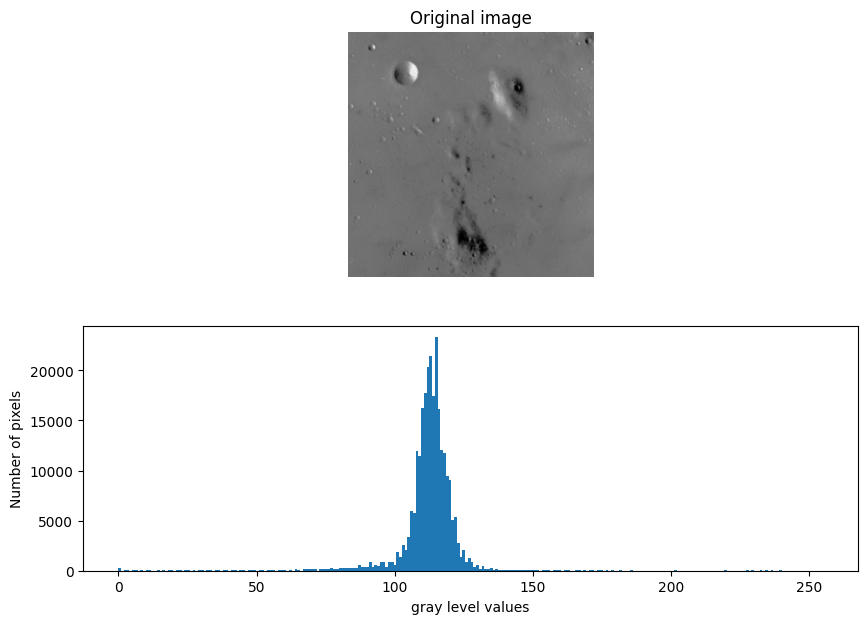

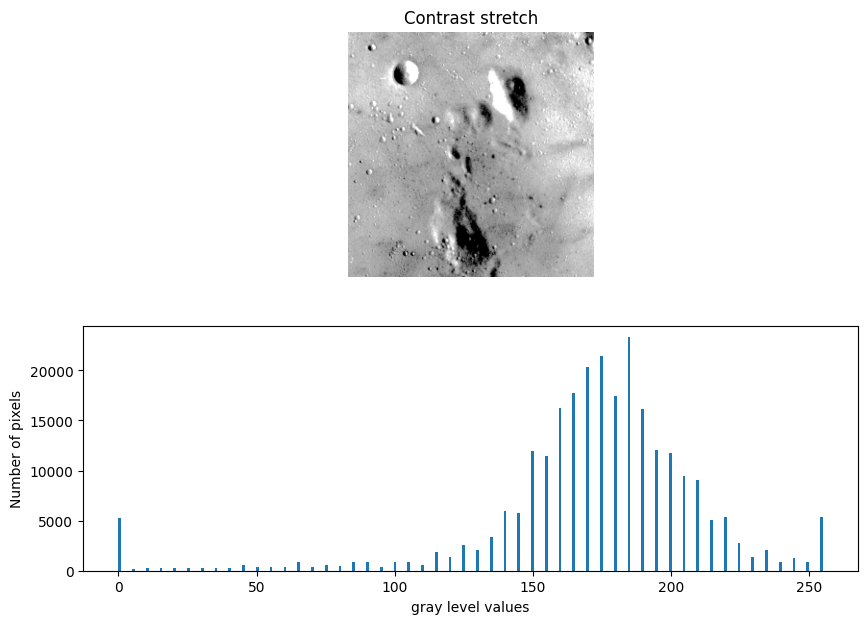

In [5]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

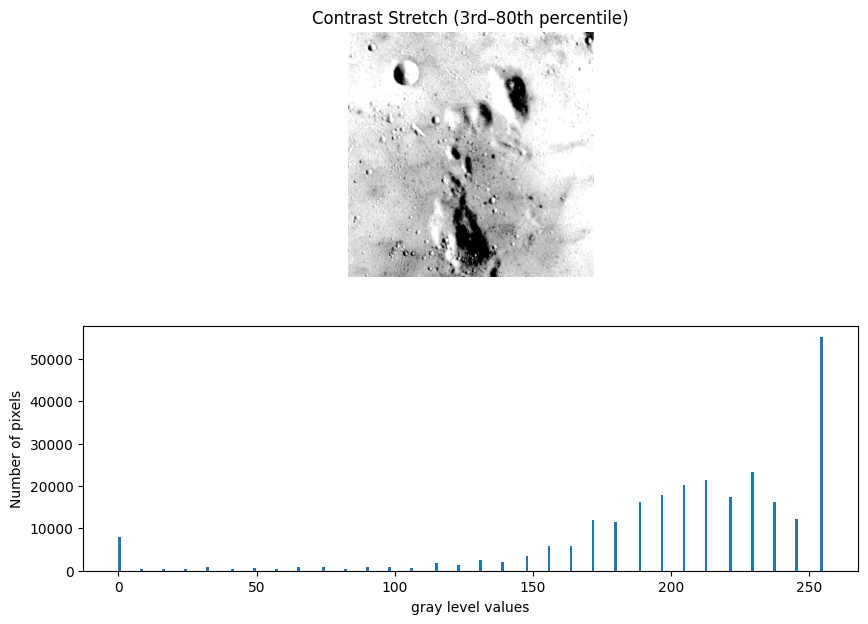

In [6]:
# Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram
p3, p80 = np.percentile(img, (3, 80))
img_task1 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_task1, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch (3rd–80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_task1.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

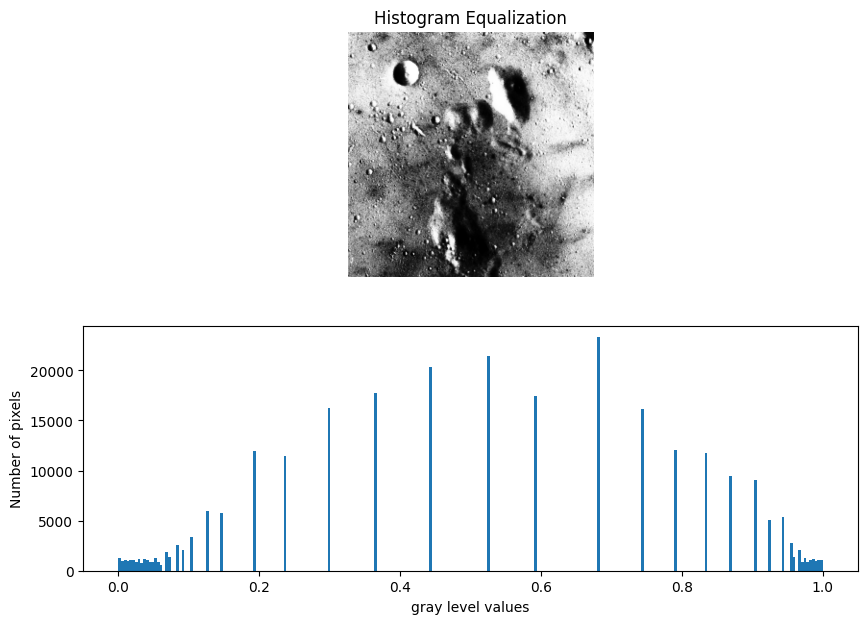

In [7]:
# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256)
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

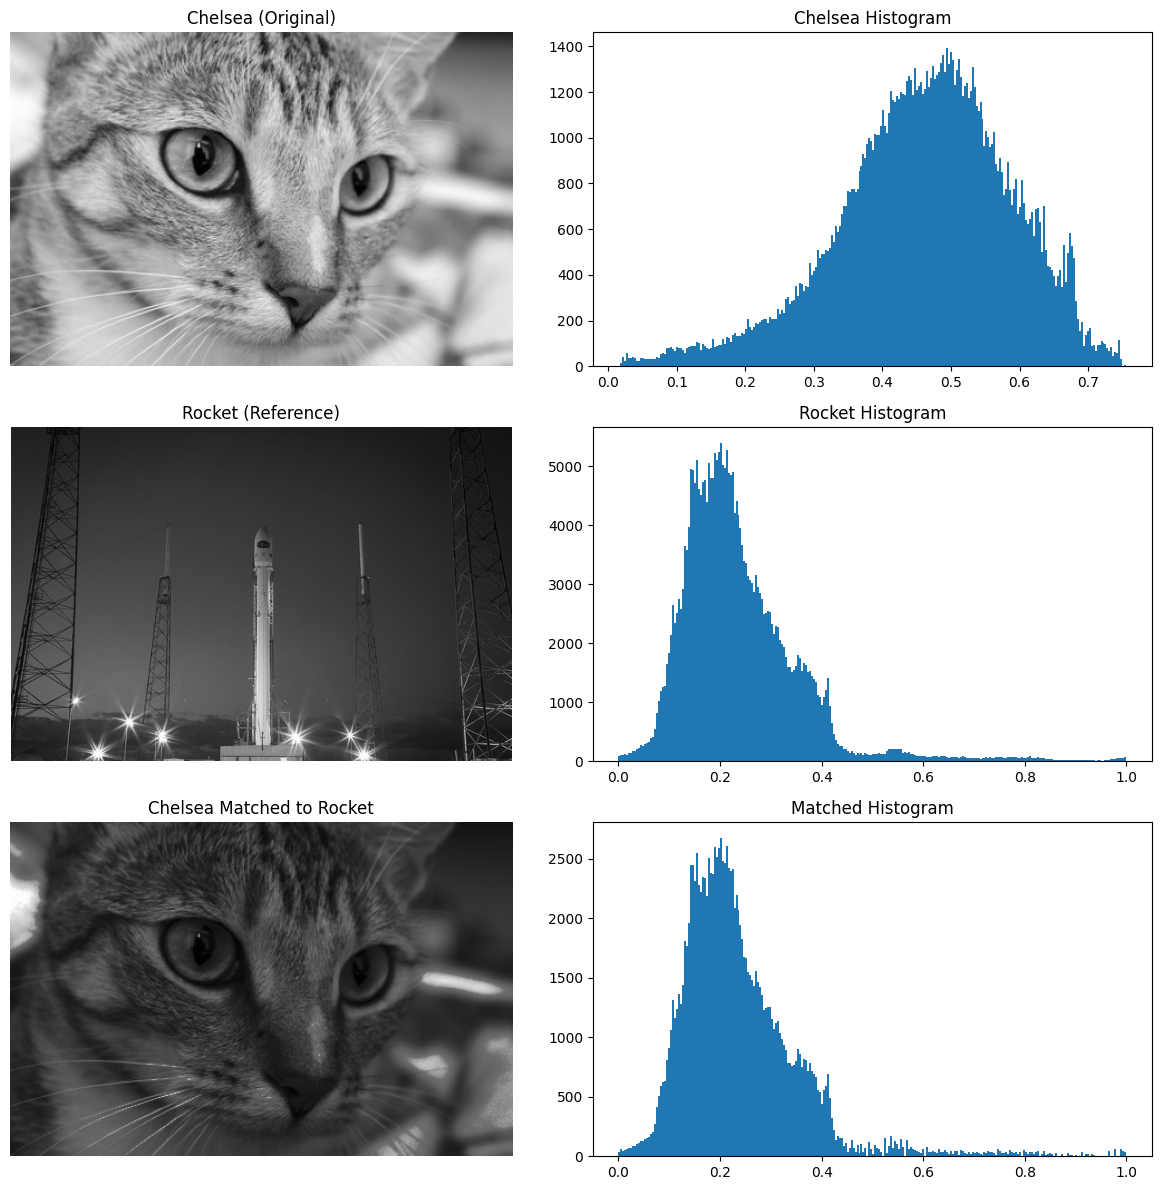

In [8]:
# Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching
from skimage import color

# Load images
chelsea = data.chelsea()       # target image
rocket = data.rocket()         # reference image

# Convert both to grayscale for matching
chelsea_gray = color.rgb2gray(chelsea)
rocket_gray = color.rgb2gray(rocket)

# Perform histogram matching
matched = exposure.match_histograms(chelsea_gray, rocket_gray)

# Display results
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes[0, 0].imshow(chelsea_gray, cmap='gray')
axes[0, 0].set_title('Chelsea (Original)')
axes[0, 0].axis('off')
axes[0, 1].hist(chelsea_gray.flat, bins=256)
axes[0, 1].set_title('Chelsea Histogram')

axes[1, 0].imshow(rocket_gray, cmap='gray')
axes[1, 0].set_title('Rocket (Reference)')
axes[1, 0].axis('off')
axes[1, 1].hist(rocket_gray.flat, bins=256)
axes[1, 1].set_title('Rocket Histogram')

axes[2, 0].imshow(matched, cmap='gray')
axes[2, 0].set_title('Chelsea Matched to Rocket')
axes[2, 0].axis('off')
axes[2, 1].hist(matched.flat, bins=256)
axes[2, 1].set_title('Matched Histogram')

plt.tight_layout()
plt.show()